In [21]:
import pandas as pd

In [22]:
df = pd.read_csv('dataflame_dea.csv')

In [23]:
print(list(df.columns))

['Unnamed: 0', '都道府県', '総人口', '医師数', '薬剤師数', '一般病院数', '一般診療所数', '病院在院患者数', '病院病床数', '診療所在院患者数', '診療所病床数', '１日平均外来患者数合計', '年間外来患者数', '在院患者総数', '病床総数', '一般病院数_人口10万人あたり', '医師数_人口10万人あたり', '薬剤師数_人口10万人あたり', '一般診療所数_人口10万人あたり', '病院患者数_人口10万人あたり', '病院病床数_人口10万人あたり', '診療所患者数_人口10万人あたり', '診療所病床数_人口10万人あたり', '患者総数_人口10万人あたり', '病床総数_人口10万人あたり', '１日平均外来患者数合計_人口10万人あたり', '効率値-in', '効率値-out']


In [24]:
df = df[['都道府県','一般病院数_人口10万人あたり', '医師数_人口10万人あたり', '薬剤師数_人口10万人あたり', '一般診療所数_人口10万人あたり', '病院患者数_人口10万人あたり', '病院病床数_人口10万人あたり', '診療所患者数_人口10万人あたり', '診療所病床数_人口10万人あたり','病床総数_人口10万人あたり', '１日平均外来患者数合計_人口10万人あたり','効率値-in']]

In [25]:
df

,都道府県,一般病院数_人口10万人あたり,医師数_人口10万人あたり,薬剤師数_人口10万人あたり,一般診療所数_人口10万人あたり,病院患者数_人口10万人あたり,病院病床数_人口10万人あたり,診療所患者数_人口10万人あたり,診療所病床数_人口10万人あたり,病床総数_人口10万人あたり,１日平均外来患者数合計_人口10万人あたり,効率値-in
0,北海道,9.163424,267.140078,229.610895,66.147860,109845.642023,4253.618677,450.389105,40.700389,4294.319066,15450.291829,1.000000
1,青森県,6.312292,230.315615,194.767442,72.259136,59046.594684,2301.578073,449.169435,23.172757,2324.750831,12560.797342,1.000000
2,岩手県,6.519898,228.619814,214.733277,75.190517,47371.210838,1973.751058,16.511431,27.180356,2000.931414,11191.701948,0.961478
3,宮城県,4.780702,260.964912,241.315789,75.131579,42008.815789,1641.622807,393.333333,26.052632,1667.675439,10136.578947,1.000000
4,秋田県,5.376344,262.795699,222.150538,88.387097,58032.580645,2238.709677,739.032258,30.000000,2268.709677,13419.247312,0.984062
5,山形県,5.091258,250.528338,204.514890,87.704131,63562.728146,2359.654179,554.082613,18.155620,2377.809798,12357.060519,1.000000
6,福島県,5.642458,221.117318,211.843575,76.648045,48684.860335,1952.737430,0.000000,13.575419,1966.312849,11825.474860,0.994886
7,茨城県,5.352113,205.563380,236.056338,62.676056,51725.035211,2162.218310,336.338028,16.408451,2178.626761,11540.598592,1.000000
8,栃木県,4.662127,250.026192,227.867994,77.527501,58766.474594,2318.386590,211.052907,15.086433,2333.473023,11886.066003,0.972334
9,群馬県,6.011500,247.516989,215.891270,82.958704,61982.749608,2413.277574,153.058024,3.763722,2417.041296,11446.628332,0.916465


In [26]:
from sklearn.preprocessing import StandardScaler

# 例として、都道府県ごとのデータフレームdfがあるとします
# df = pd.read_csv('your_prefecture_data.csv') 
# dfには '都道府県名', '医師数', '病床数', '外来患者数' などの列があると仮定

# 1. 分析に使う列を選択
features = ['一般病院数_人口10万人あたり', '医師数_人口10万人あたり', '薬剤師数_人口10万人あたり',
             '一般診療所数_人口10万人あたり', '病院患者数_人口10万人あたり', '病院病床数_人口10万人あたり', 
             '診療所患者数_人口10万人あたり', '診療所病床数_人口10万人あたり',
               '病床総数_人口10万人あたり', '１日平均外来患者数合計_人口10万人あたり']
X = df[features]

# (オプション) 欠損値がある場合は処理する
X = X.dropna()

# 2. データを標準化する
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

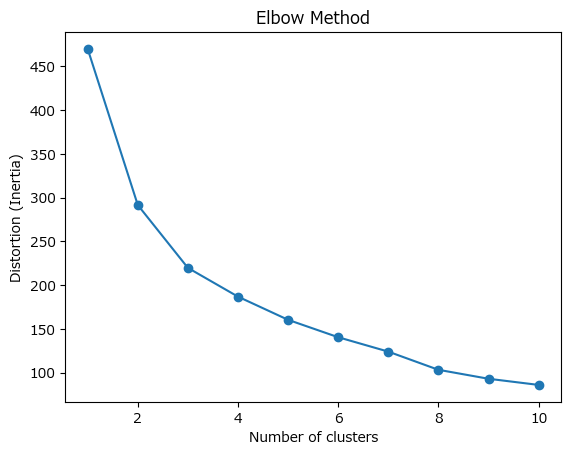

In [27]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# 各クラスター数で計算したときの誤差の総和を格納するリスト
distortions = []

# クラスター数を1から10まで変えて計算
for i in range(1, 11):
    km = KMeans(n_clusters=i, init='k-means++', n_init=10, max_iter=300, random_state=0)
    km.fit(X_scaled)
    distortions.append(km.inertia_)

# 結果をプロット
plt.plot(range(1, 11), distortions, marker='o')
plt.xlabel('Number of clusters')
plt.ylabel('Distortion (Inertia)')
plt.title('Elbow Method')
plt.show()

In [28]:
df

,都道府県,一般病院数_人口10万人あたり,医師数_人口10万人あたり,薬剤師数_人口10万人あたり,一般診療所数_人口10万人あたり,病院患者数_人口10万人あたり,病院病床数_人口10万人あたり,診療所患者数_人口10万人あたり,診療所病床数_人口10万人あたり,病床総数_人口10万人あたり,１日平均外来患者数合計_人口10万人あたり,効率値-in
0,北海道,9.163424,267.140078,229.610895,66.147860,109845.642023,4253.618677,450.389105,40.700389,4294.319066,15450.291829,1.000000
1,青森県,6.312292,230.315615,194.767442,72.259136,59046.594684,2301.578073,449.169435,23.172757,2324.750831,12560.797342,1.000000
2,岩手県,6.519898,228.619814,214.733277,75.190517,47371.210838,1973.751058,16.511431,27.180356,2000.931414,11191.701948,0.961478
3,宮城県,4.780702,260.964912,241.315789,75.131579,42008.815789,1641.622807,393.333333,26.052632,1667.675439,10136.578947,1.000000
4,秋田県,5.376344,262.795699,222.150538,88.387097,58032.580645,2238.709677,739.032258,30.000000,2268.709677,13419.247312,0.984062
5,山形県,5.091258,250.528338,204.514890,87.704131,63562.728146,2359.654179,554.082613,18.155620,2377.809798,12357.060519,1.000000
6,福島県,5.642458,221.117318,211.843575,76.648045,48684.860335,1952.737430,0.000000,13.575419,1966.312849,11825.474860,0.994886
7,茨城県,5.352113,205.563380,236.056338,62.676056,51725.035211,2162.218310,336.338028,16.408451,2178.626761,11540.598592,1.000000
8,栃木県,4.662127,250.026192,227.867994,77.527501,58766.474594,2318.386590,211.052907,15.086433,2333.473023,11886.066003,0.972334
9,群馬県,6.011500,247.516989,215.891270,82.958704,61982.749608,2413.277574,153.058024,3.763722,2417.041296,11446.628332,0.916465


In [29]:
# 最適なクラスター数を4としてK-Meansを実行
k = 4
kmeans = KMeans(n_clusters=k, init='k-means++', n_init=10, max_iter=300, random_state=0)
clusters = kmeans.fit_predict(X_scaled)

# 元のデータフレームにクラスター番号の列を追加
df['cluster'] = clusters

print(df[['都道府県', 'cluster']].head())

  都道府県  cluster
0  北海道        1
1  青森県        2
2  岩手県        2
3  宮城県        2
4  秋田県        2


In [30]:
# 各クラスターの平均値を計算して特徴を把握
cluster_summary = df.groupby('cluster')[features].mean()
print(cluster_summary)

         一般病院数_人口10万人あたり  医師数_人口10万人あたり  薬剤師数_人口10万人あたり  一般診療所数_人口10万人あたり  \
cluster                                                                     
0               5.413186     315.783476      285.636795         99.289765   
1               8.461416     300.663524      239.220463         87.319817   
2               4.846468     236.674915      219.565673         75.941871   
3              11.737616     321.973663      264.278848         92.420174   

         病院患者数_人口10万人あたり  病院病床数_人口10万人あたり  診療所患者数_人口10万人あたり  診療所病床数_人口10万人あたり  \
cluster                                                                         
0           62428.517471      2375.512414        150.642125          7.554338   
1           83156.595278      3310.064016        920.442285         57.856965   
2           54245.330449      2112.277756        364.801018         18.900377   
3          152674.555910      5867.143392       1774.072441        113.359528   

         病床総数_人口10万人あたり  １日平均外来患者数合計_人口10万人あたり  
c

In [31]:
# 0	大都市・専門分化型	専門家とクリニックは多いが、病床は少ない。機能分化が進んだ都市部。
# 1	地方中核都市型	全体的にバランスが取れた、標準的な医療体制を持つ地域。
# 2	資源希少・地方型	全体的に医療資源が少なく、アクセスに課題がある可能性のある地域。
# 3	医療資源・需要集中型	病床数と患者数が突出して多く、病院中心の医療体制が強い地域

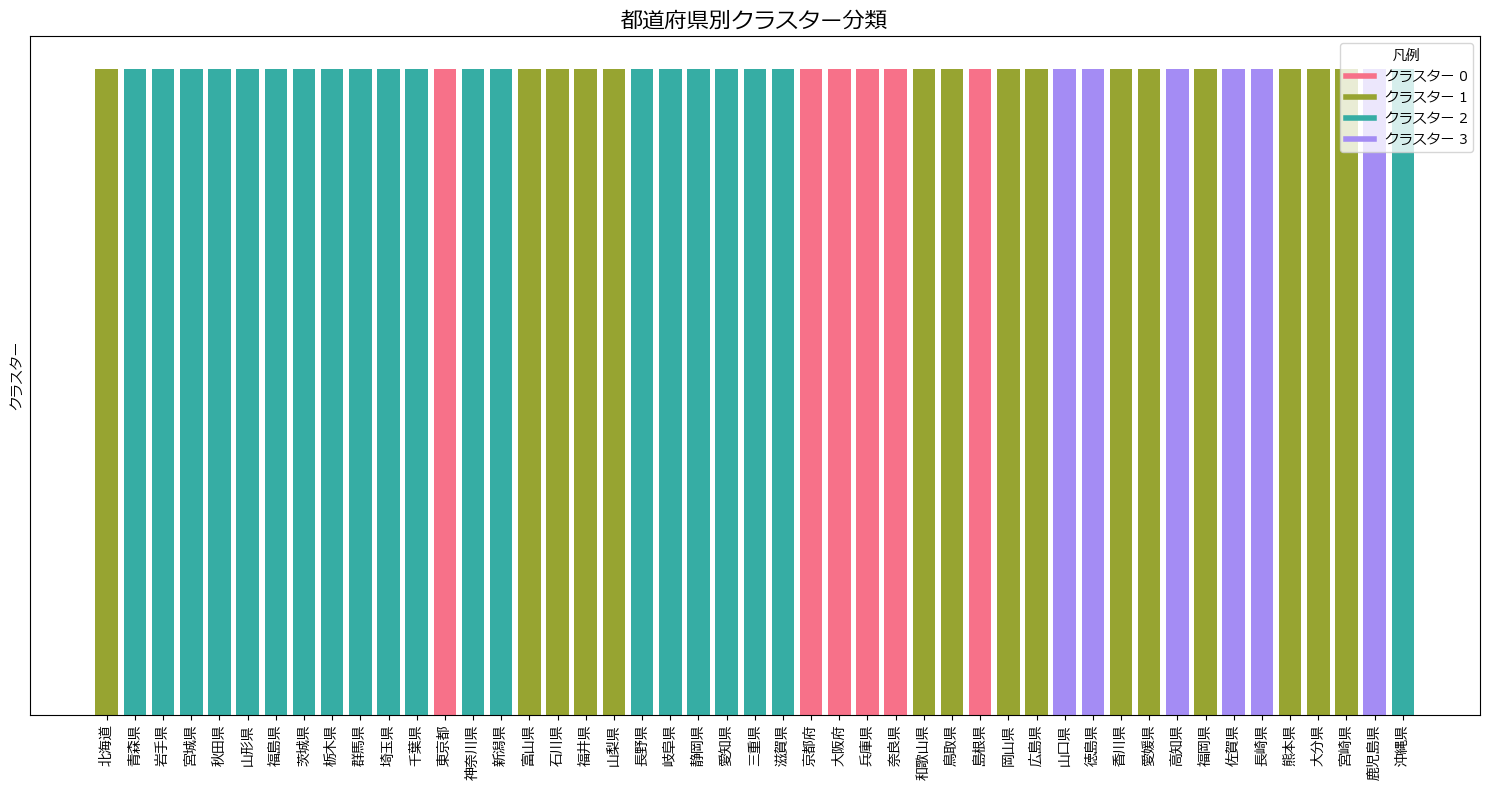

In [32]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 前のステップでクラスター番号が追加されたdfがあると仮定します
# df['cluster'] には 0, 1, 2, 3... のような番号が入っています

# 日本語表示のためのフォント設定
plt.rcParams['font.family'] = 'Meiryo' # Windowsの場合

# 描画の準備
plt.figure(figsize=(15, 8))

# seabornのカラーパレットを使ってクラスターごとに色を自動で設定
palette = sns.color_palette("husl", n_colors=k) # kはクラスター数

# 都道府県ごとに棒グラフを作成
bars = plt.bar(df['都道府県'], [1] * len(df), color=[palette[i] for i in df['cluster']])

# グラフの見た目を調整
plt.title('都道府県別クラスター分類', fontsize=16)
plt.ylabel('クラスター')
plt.xticks(rotation=90) # 都道府県名が重ならないように90度回転
plt.yticks([]) # y軸の目盛りは不要なので消す

# 凡例（どの色がどのクラスターか）を作成
from matplotlib.lines import Line2D
legend_elements = [Line2D([0], [0], color=palette[i], lw=4, label=f'クラスター {i}') for i in range(k)]
plt.legend(handles=legend_elements, title="凡例")

plt.tight_layout() # レイアウトを自動調整
plt.show()

In [33]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

# 都道府県ごとのデータフレームdfがあると仮定します
# df = pd.read_csv('your_prefecture_data.csv') 

# 1. 分析に使う列を選択
features = ['一般病院数_人口10万人あたり', '医師数_人口10万人あたり', '薬剤師数_人口10万人あたり', 
            '一般診療所数_人口10万人あたり', '病院患者数_人口10万人あたり', '病院病床数_人口10万人あたり',
            '診療所患者数_人口10万人あたり', '診療所病床数_人口10万人あたり', '病床総数_人口10万人あたり',
            '１日平均外来患者数合計_人口10万人あたり']
X = df[features].dropna() # 欠損値がある場合は除外

# 2. データを標準化する
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [34]:
from sklearn.decomposition import PCA

# n_components=2 として、2つの主成分を抽出する
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# 結果をDataFrameに変換
pca_df = pd.DataFrame(data=X_pca, columns=['PC1', 'PC2'])

# 元のデータにあった都道府県名やクラスター番号も結合しておく
# (dfのインデックスとpca_dfのインデックスが合っていることを確認)
pca_df['都道府県'] = df['都道府県']
if 'cluster' in df.columns:
    pca_df['cluster'] = df['cluster']

print(pca_df.head())

        PC1       PC2 都道府県  cluster
0  1.253999 -1.792600  北海道        1
1 -1.611153 -1.348786  青森県        2
2 -2.113457 -0.741621  岩手県        2
3 -2.317677  0.160321  宮城県        2
4 -0.930065  0.167024  秋田県        2


In [35]:
# 各主成分の寄与率
print(f"第一主成分(PC1)の寄与率: {pca.explained_variance_ratio_[0]:.2%}")
print(f"第二主成分(PC2)の寄与率: {pca.explained_variance_ratio_[1]:.2%}")
print(f"累積寄与率 (PC1 + PC2): {pca.explained_variance_ratio_.sum():.2%}")

第一主成分(PC1)の寄与率: 54.73%
第二主成分(PC2)の寄与率: 15.88%
累積寄与率 (PC1 + PC2): 70.60%


In [36]:
# 主成分負荷量をDataFrameで表示
loadings_df = pd.DataFrame(pca.components_.T, 
                           columns=['PC1', 'PC2'], 
                           index=features)
print(loadings_df)

                            PC1       PC2
一般病院数_人口10万人あたり        0.390458 -0.140609
医師数_人口10万人あたり          0.311373  0.436497
薬剤師数_人口10万人あたり         0.138458  0.570563
一般診療所数_人口10万人あたり       0.200181  0.583630
病院患者数_人口10万人あたり        0.378407 -0.182968
病院病床数_人口10万人あたり        0.385433 -0.181466
診療所患者数_人口10万人あたり       0.265840 -0.071106
診療所病床数_人口10万人あたり       0.267947 -0.130222
病床総数_人口10万人あたり         0.389234 -0.183409
１日平均外来患者数合計_人口10万人あたり  0.325002 -0.038395


In [37]:
# 	PC2 高 (都市型)	PC2 低 (病院完結型)
# PC1 高 (大規模)	医療資源が豊富で、専門クリニックが多い大都市（例：東京、大阪）	医療資源が豊富で、大規模病院が中心の地方中核都市（例：福岡、札幌）
# PC1 低 (小規模)	医療規模は小さいが、比較的クリニックが充実している都市近郊の県	医療規模が小さく、少数の基幹病院に依存する地方の県

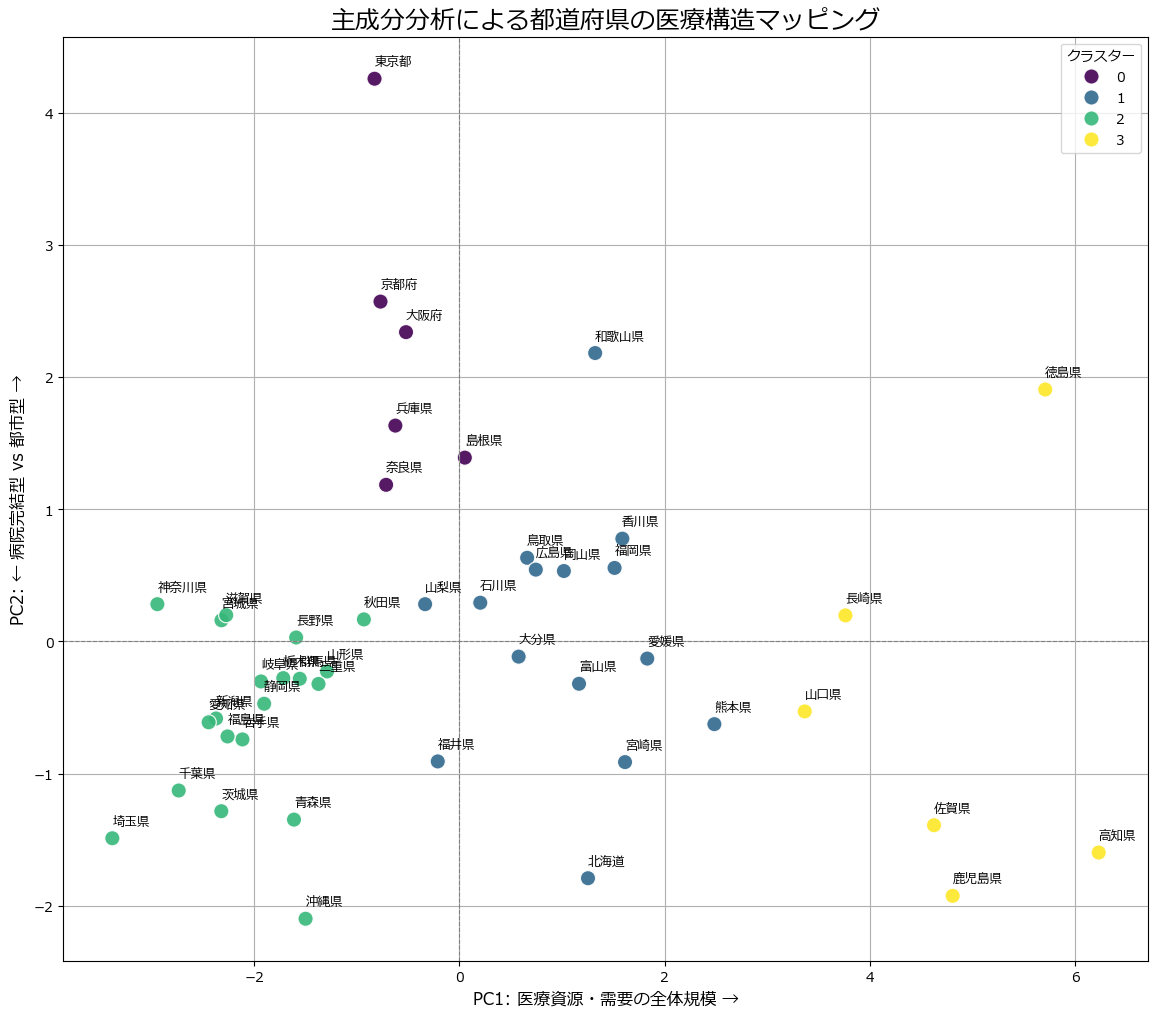

In [38]:

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd # pca_dfを作成するために必要

# --- この部分は、前のステップで実行済みと仮定 ---
# 仮のデータを作成します。実際にはご自身のデータを使用してください。
# X_pca, df['都道府県名'], df['cluster'] は計算済みとします。
# pca_df = pd.DataFrame(data=X_pca, columns=['PC1', 'PC2'])
# pca_df['都道府県名'] = df['都道府県名']
# pca_df['cluster'] = df['cluster']
# --- ここまで ---


# 日本語表示のためのフォント設定
plt.rcParams['font.family'] = 'Meiryo' # Windowsの場合
# plt.rcParams['font.family'] = 'Hiragino Sans' # Macの場合

# グラフのサイズを設定
plt.figure(figsize=(14, 12))

# seabornを使って、クラスター番号で色分けした散布図を作成
sns.scatterplot(
    x='PC1',
    y='PC2',
    hue='cluster',  # クラスター分析の結果で色を分ける
    palette='viridis',  # カラーパレット（'plasma', 'magma'などもおすすめ）
    data=pca_df,
    s=120,          # 点のサイズ
    alpha=0.9
)

# 各点に都道府県名を表示
for i, txt in enumerate(pca_df['都道府県']):
    plt.text(pca_df['PC1'][i], pca_df['PC2'][i] + 0.1, txt, fontsize=9)

# タイトルと軸ラベル（先ほどの解釈を反映）
plt.title('主成分分析による都道府県の医療構造マッピング', fontsize=18)
plt.xlabel('PC1: 医療資源・需要の全体規模 →', fontsize=12)
plt.ylabel('PC2: ← 病院完結型 vs 都市型 →', fontsize=12)

# 補助線
plt.grid()
plt.axhline(0, color='grey', linewidth=0.8, linestyle='--')
plt.axvline(0, color='grey', linewidth=0.8, linestyle='--')

plt.legend(title='クラスター')
plt.show()

In [46]:
import pandas as pd
import geopandas as gpd
from pysal.lib import weights
from esda.moran import Moran

# df はあなたの統計データ（都道府県名、医師数など）のDataFrameとします

# 1. 都道府県の地図データ（シェープファイル）を読み込む
# 注意: 'path/to/japan.shp' と 'PREF_NAME' は、
#      お持ちのシェープファイルのパスと都道府県名が格納されている列名に置き換えてください。
try:
    jp_map = gpd.read_file('../data/japan.shp', encoding='cp932')
except Exception as e:
    print(f"シェープファイルの読み込みに失敗しました: {e}")
    # ここで処理を中断するか、適切なエラーハンドリングを行う

# 2. 地図データとあなたの統計データを、都道府県名をキーにして結合する
# merged_map_df が 'geometry' 列を持つ GeoDataFrame になります
# 注意: 'left_on'と'right_on'の列名は、それぞれのファイルに合わせて変更してください。
merged_map_df = pd.merge(
    jp_map,
    df,
    left_on='N03_001',      # 確認した地図データ側の正しい列名に修正
    right_on='都道府県'     # 確認した統計データ側の正しい列名に修正
)

# 3. 結合したGeoDataFrameを使って、隣接関係を定義する
# これでエラーは発生しなくなります
wq = weights.Queen.from_dataframe(merged_map_df)

# 4. 分析したい変数を選択
y = merged_map_df['医師数_人口10万人あたり']

# 5. モランのIを計算
moran = Moran(y, wq)

# 結果を表示
print("--- 空間的自己相関分析の結果 ---")
print(f"Moran's I: {moran.I:.4f}")
print(f"p-value: {moran.p_sim:.4f}")

C:\Users\junco\AppData\Local\Temp\ipykernel_25248\3299751526.py:29: FutureWarning: `use_index` defaults to False but will default to True in future. Set True/False directly to control this behavior and silence this warning
  wq = weights.Queen.from_dataframe(merged_map_df)
c:\Users\junco\anaconda3\envs\healthcare-env\Lib\site-packages\libpysal\weights\contiguity.py:347: UserWarning: The weights matrix is not fully connected: 
 There are 120763 disconnected components.
 There are 120693 islands with ids: 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 

('WARNING: ', 10, ' is an island (no neighbors)')
('WARNING: ', 11, ' is an island (no neighbors)')
('WARNING: ', 12, ' is an island (no neighbors)')
('WARNING: ', 13, ' is an island (no neighbors)')
('WARNING: ', 14, ' is an island (no neighbors)')
('WARNING: ', 15, ' is an island (no neighbors)')
('WARNING: ', 16, ' is an island (no neighbors)')
('WARNING: ', 17, ' is an island (no neighbors)')
('WARNING: ', 18, ' is an island (no neighbors)')
('WARNING: ', 19, ' is an island (no neighbors)')
('WARNING: ', 20, ' is an island (no neighbors)')
('WARNING: ', 21, ' is an island (no neighbors)')
('WARNING: ', 22, ' is an island (no neighbors)')
('WARNING: ', 23, ' is an island (no neighbors)')
('WARNING: ', 24, ' is an island (no neighbors)')
('WARNING: ', 25, ' is an island (no neighbors)')
('WARNING: ', 26, ' is an island (no neighbors)')
('WARNING: ', 27, ' is an island (no neighbors)')
('WARNING: ', 28, ' is an island (no neighbors)')
('WARNING: ', 29, ' is an island (no neighbors)')


In [47]:
# 地図データ（GeoDataFrame）の列名一覧を表示
print("地図データの列名:", jp_map.columns)

# あなたの統計データ（DataFrame）の列名一覧を表示
print("統計データの列名:", df.columns)

地図データの列名: Index(['OBJECTID', 'N03_001', 'N03_002', 'N03_003', 'N03_004', 'N03_007',
       'Shape_Leng', 'Shape_Area', 'geometry'],
      dtype='object')
統計データの列名: Index(['都道府県', '一般病院数_人口10万人あたり', '医師数_人口10万人あたり', '薬剤師数_人口10万人あたり',
       '一般診療所数_人口10万人あたり', '病院患者数_人口10万人あたり', '病院病床数_人口10万人あたり',
       '診療所患者数_人口10万人あたり', '診療所病床数_人口10万人あたり', '病床総数_人口10万人あたり',
       '１日平均外来患者数合計_人口10万人あたり', '効率値-in', 'cluster'],
      dtype='object')


In [48]:
y = merged_map_df['効率値-in']

# 3. モランのIを計算
moran = Moran(y, wq)

# 結果の表示 (I: モラン指数, p_sim: p値)
print(f"Moran's I: {moran.I:.4f}")
print(f"p-value: {moran.p_sim:.4f}")

Moran's I: 1.1965
p-value: 0.0010


In [49]:
y = merged_map_df['一般病院数_人口10万人あたり']

# 3. モランのIを計算
moran = Moran(y, wq)

# 結果の表示 (I: モラン指数, p_sim: p値)
print(f"Moran's I: {moran.I:.4f}")
print(f"p-value: {moran.p_sim:.4f}")

Moran's I: 0.8280
p-value: 0.0010


In [50]:
y = merged_map_df['１日平均外来患者数合計_人口10万人あたり']

# 3. モランのIを計算
moran = Moran(y, wq)

# 結果の表示 (I: モラン指数, p_sim: p値)
print(f"Moran's I: {moran.I:.4f}")
print(f"p-value: {moran.p_sim:.4f}")

Moran's I: 0.8011
p-value: 0.0010


In [51]:
y = merged_map_df['一般診療所数_人口10万人あたり']

# 3. モランのIを計算
moran = Moran(y, wq)

# 結果の表示 (I: モラン指数, p_sim: p値)
print(f"Moran's I: {moran.I:.4f}")
print(f"p-value: {moran.p_sim:.4f}")

Moran's I: 0.8822
p-value: 0.0010


In [53]:
df_e = pd.read_csv('../data/ssdse_E_cleaned.csv')

In [54]:
print(list(df_e.columns))

['地域コード', '都道府県', '総人口', '日本人人口', '15歳未満人口', '15〜64歳人口', '65歳以上人口', '外国人人口', '出生数', '合計特殊出生率', '死亡数', '転入者数（日本人移動者）', '転出者数（日本人移動者）', '一般世帯数', '一般世帯人員数', '単独世帯数', '婚姻件数', '離婚件数', '総面積（北方地域及び竹島を除く）', '可住地面積', '自然公園面積', '県内総生産額（平成27年基準）', '県民所得（平成27年基準）', '1人当たり県民所得（平成27年基準）', '事業所数（民営）', '事業所数（民営）（建設業）', '事業所数（民営）（製造業）', '事業所数（民営）（情報通信業）', '事業所数（民営）（卸売業、小売業）', '事業所数（民営）（宿泊業、飲食サービス業）', '事業所数（民営）（生活関連サービス業、娯楽業）', '事業所数（民営）（医療、福祉）', '従業者数（民営）', '従業者数（民営）（建設業）', '従業者数（民営）（製造業）', '従業者数（民営）（情報通信業）', '従業者数（民営）（卸売業、小売業）', '従業者数（民営）（宿泊業、飲食サービス業）', '従業者数（民営）（生活関連サービス業、娯楽業）', '従業者数（民営）（医療、福祉）', '農家数（販売農家）', '農家数（自給的農家）', '耕地面積', '旅館営業施設数（ホテルを含む）', '旅館営業施設客室数（ホテルを含む）', '幼稚園数', '幼稚園在園者数', '小学校数', '小学校児童数', '中学校数', '中学校生徒数', '高等学校数', '高等学校生徒数', '短期大学数', '大学数', '短期大学学生数', '大学学生数', '公民館数', '図書館数', '博物館数', '劇場、音楽堂等数', '社会体育施設数', '民間体育施設数', '映画館数', '一般旅券発行件数', '延べ宿泊者数', '外国人延べ宿泊者数', '総住宅数', '空き家数', '持ち家数', '一戸建住宅数', '1住宅当たり延べ面積', '総人口（非水洗化人口＋水洗化人口）', '非水洗化人口', 'ごみ総排出量（総量）', '1人1日当たりの排出量', 'ごみのリサイクル率', '小

In [55]:
df_e = df_e[['都道府県','総人口',  '65歳以上人口']]

In [60]:
df_e[['総人口', '65歳以上人口']] = (
    df_e[['総人口', '65歳以上人口']]
    .replace({',': ''}, regex=True)          # カンマを削除
    .replace({'　': '', ' ': ''}, regex=True) # 空白を削除（全角・半角）
    .apply(pd.to_numeric, errors='coerce')    # 数値変換、変換できない値はNaNに
    .astype('Int64')                          # 欠損値対応の整数型に
)

In [61]:
df_e['65歳以上割合']=df_e['65歳以上人口']/df_e['総人口']

In [64]:
df_e = df_e.drop(index=[0,1])

In [65]:
df_e

,都道府県,総人口,65歳以上人口,65歳以上割合
2,北海道,5140000,1686000,0.328016
3,青森県,1204000,419000,0.348007
4,岩手県,1181000,408000,0.34547
5,宮城県,2280000,659000,0.289035
6,秋田県,930000,359000,0.386022
7,山形県,1041000,362000,0.347743
8,福島県,1790000,586000,0.327374
9,茨城県,2840000,864000,0.304225
10,栃木県,1909000,572000,0.299633
11,群馬県,1913000,589000,0.307893


In [66]:
df_c = pd.read_csv('../data/ssdse_C_cleaned.csv')

In [69]:
print(list(df_c.columns))

['地域コード', '都道府県', '市', '世帯人員', '食料（合計）', '01\u3000穀類', '米', '食パン', '他のパン', '生うどん・そば', '乾うどん・そば', 'パスタ', '中華麺', 'カップ麺', '即席麺', '他の麺類', '小麦粉', 'もち', '他の穀類のその他', '02\u3000魚介類', 'まぐろ', 'あじ', 'いわし', 'かつお', 'かれい', 'さけ', 'さば', 'さんま', 'たい', 'ぶり', 'いか', 'たこ', 'えび', 'かに', '他の鮮魚', 'さしみ盛合わせ', 'あさり', 'しじみ', 'かき（貝）', 'ほたて貝', '他の貝', '塩さけ', 'たらこ', 'しらす干し', '干しあじ', '他の塩干魚介', '揚げかまぼこ', 'ちくわ', 'かまぼこ', '他の魚肉練製品', 'かつお節・削り節', '魚介の漬物', '魚介のつくだ煮', '魚介の缶詰', '他の魚介加工品のその他', '03\u3000肉類', '牛肉', '豚肉', '鶏肉', '合いびき肉', '他の生鮮肉', 'ハム', 'ソーセージ', 'ベーコン', '他の加工肉', '04\u3000乳卵類', '牛乳', '粉ミルク', 'ヨーグルト', 'バター', 'チーズ', '他の乳製品', '卵', '05\u3000野菜・海藻', 'キャベツ', 'ほうれんそう', 'はくさい', 'ねぎ', 'レタス', 'ブロッコリー', 'もやし', '他の葉茎菜', 'さつまいも', 'じゃがいも', 'さといも', 'だいこん', 'にんじん', 'ごぼう', 'たまねぎ', 'れんこん', 'たけのこ', '他の根菜', 'さやまめ', 'かぼちゃ', 'きゅうり', 'なす', 'トマト', 'ピーマン', '生しいたけ', 'しめじ', 'えのきたけ', '他のきのこ', '他の野菜のその他', '豆類', '干ししいたけ', '干しのり', 'わかめ', 'こんぶ', '他の乾物・海藻', '豆腐', '油揚げ・がんもどき', '納豆', '他の大豆製品', 'こんにゃく', '梅干し', 'だいこん漬', 'はくさい漬', '他の野菜の漬物', 'こんぶつくだ煮', '他の野菜

In [70]:
df_c = df_c[['都道府県','食料（合計）']]

In [71]:
df_ce = pd.merge(df_c,df_e,on ='都道府県')

In [79]:
df_iryohi = pd.read_excel('../data/国民医療費.xlsx')

In [80]:
df_ice = pd.merge(df_ce,df_iryohi,on='都道府県')

In [81]:
df = pd.merge(df,df_ice,on='都道府県')

In [82]:
df = df.rename(columns={'食料（合計）':'食料家計消費額'})

In [88]:
print(list(df.columns))

['都道府県', '一般病院数_人口10万人あたり', '医師数_人口10万人あたり', '薬剤師数_人口10万人あたり', '一般診療所数_人口10万人あたり', '病院患者数_人口10万人あたり', '病院病床数_人口10万人あたり', '診療所患者数_人口10万人あたり', '診療所病床数_人口10万人あたり', '病床総数_人口10万人あたり', '１日平均外来患者数合計_人口10万人あたり', '効率値-in', 'cluster', '食料家計消費額', '総人口_x', '65歳以上人口_x', '65歳以上割合_x', '食料家計消費額', '総人口_y', '65歳以上人口_y', '65歳以上割合_y', 'Unnamed: 0', '総\u3000\u3000数', ' 医科診療医療費_総額', ' 医科診療医療費_入院', ' 医科診療医療費_入院外', '歯科診療医療費', '薬局調剤医療費', '入院時食事・生活医療費', '訪問看護医療費', '療養費等', '国民医療費', '総人口（千人）', 'intervention']


In [92]:
import pandas as pd
from causalinference import CausalModel

# --- データの準備 ---
# 医療資源データ、高齢化率データ、食料消費データを結合したdfがあるとします
# df の列: '都道府県名', '病床総数_人口10万人あたり', '一人あたり入院医療費', '65歳以上の割合', '食料家計消費額'

# --- 変数の定義 ---

# 1. 【介入変数】を定義
# 病床数が全国平均より多いかどうかを「介入」とします (多い=1, 少ない=0)
bed_mean = df['病床総数_人口10万人あたり'].mean()
df['intervention'] = (df['病床総数_人口10万人あたり'] > bed_mean).astype(int)

# 2. 【結果変数】を定義
# 介入によって変化したかを見たい結果
outcome = df['国民医療費'].values

# 3. 【介入変数】をベクトルとして定義
treatment = df['intervention'].values

# 4. 【共変量（調整する交絡因子）】を定義
# 手に入れた2つのデータをここで使います
covariates = df[['65歳以上割合_x', '食料家計消費額']].values

In [114]:
import pandas as pd
import numpy as np
from causalinference import CausalModel

# --- 1. データの準備 ---
# df はあなたの元のデータフレームとします

# --- 2. 徹底したデータクリーニング ---

# 2-A: 分析に必要な列だけを厳選
# ご自身の実際の列名に必ず置き換えてください
required_cols = [
    '病床総数_人口10万人あたり', 
    '国民医療費', 
    '65歳以上割合_x', 
    '食料家計消費額'
]
df_clean = df[required_cols].copy()


# 2-B: ★★★ 文字列を置換してから、数値型に変換 ★★★
# 共変量として使う列のリスト
covariate_cols = ['65歳以上割合_x', '食料家計消費額']

for col in covariate_cols:
    # まず、列を文字列型に変換し、カンマ(,)を削除
    df_clean[col] = df_clean[col].astype(str).str.replace(',', '')
    
    # その後、数値型に変換。変換できないものはNaN（欠損値）にする
    df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')


# 2-C: クリーニング後のデータ型を最終確認
print("--- クリーニング後のデータ型 ---")
print(df_clean.info())
print("-" * 30)


# 2-D: 変換によって生まれた欠損値(NaN)がある行をすべて削除
df_clean.dropna(inplace=True)


# --- 3. 変数の定義 ---
bed_mean = df_clean['病床総数_人口10万人あたり'].mean()
df_clean['intervention'] = (df_clean['病床総数_人口10万人あたり'] > bed_mean).astype(int)

outcome = df_clean['国民医療費'].values
treatment = df_clean['intervention'].values
covariates = df_clean[['65歳以上割合_x', '食料家計消費額']].values


# --- 4. CausalModelの実行 ---
# --- 4. CausalModelの実行 ---

from causalinference import CausalModel

# CausalModelを初期化
model = CausalModel(Y=outcome, D=treatment, X=covariates)

# 傾向スコアを推定
model.est_propensity_s()

# マッチングと効果の推定を一度に実行
model.est_via_matching()
    
# 分析結果を表示
print("分析が正常に完了しました！")
print(model.estimates)

--- クリーニング後のデータ型 ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 47 entries, 0 to 46
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   病床総数_人口10万人あたり  47 non-null     float64
 1   国民医療費           47 non-null     float64
 2   65歳以上割合_x       47 non-null     float64
 3   食料家計消費額         47 non-null     int64  
dtypes: float64(3), int64(1)
memory usage: 1.6 KB
None
------------------------------
分析が正常に完了しました！

Treatment Effect Estimates: Matching

                     Est.       S.e.          z      P>|z|      [95% Conf. int.]
--------------------------------------------------------------------------------
           ATE     33.445     16.191      2.066      0.039      1.710     65.180
           ATC     36.400     19.062      1.910      0.056     -0.961     73.761
           ATT     27.719     16.030      1.729      0.084     -3.701     59.138



In [115]:
import pandas as pd
from causalinference import CausalModel

# --- データの準備 ---
# 医療資源データ、高齢化率データ、食料消費データを結合したdfがあるとします
# df の列: '都道府県名', '病床総数_人口10万人あたり', '一人あたり入院医療費', '65歳以上の割合', '食料家計消費額'

# --- 変数の定義 ---

# 1. 【介入変数】を定義
# 病床数が全国平均より多いかどうかを「介入」とします (多い=1, 少ない=0)
bed_mean = df['病床総数_人口10万人あたり'].mean()
df['intervention'] = (df['病床総数_人口10万人あたり'] > bed_mean).astype(int)

# 2. 【結果変数】を定義
# 介入によって変化したかを見たい結果
outcome = df[' 医科診療医療費_入院'].values

# 3. 【介入変数】をベクトルとして定義
treatment = df['intervention'].values

# 4. 【共変量（調整する交絡因子）】を定義
# 手に入れた2つのデータをここで使います
covariates = df[['65歳以上割合_x', '食料家計消費額']].values

In [117]:
import pandas as pd
import numpy as np
from causalinference import CausalModel

# --- 1. データの準備 ---
# df はあなたの元のデータフレームとします

# --- 2. 徹底したデータクリーニング ---

# 2-A: 分析に必要な列だけを厳選
# ご自身の実際の列名に必ず置き換えてください
required_cols = [
    '病床総数_人口10万人あたり', 
    ' 医科診療医療費_入院', 
    '65歳以上割合_x', 
    '食料家計消費額'
]
df_clean = df[required_cols].copy()


# 2-B: ★★★ 文字列を置換してから、数値型に変換 ★★★
# 共変量として使う列のリスト
covariate_cols = ['65歳以上割合_x', '食料家計消費額']

for col in covariate_cols:
    # まず、列を文字列型に変換し、カンマ(,)を削除
    df_clean[col] = df_clean[col].astype(str).str.replace(',', '')
    
    # その後、数値型に変換。変換できないものはNaN（欠損値）にする
    df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')


# 2-C: クリーニング後のデータ型を最終確認
print("--- クリーニング後のデータ型 ---")
print(df_clean.info())
print("-" * 30)


# 2-D: 変換によって生まれた欠損値(NaN)がある行をすべて削除
df_clean.dropna(inplace=True)


# --- 3. 変数の定義 ---
bed_mean = df_clean['病床総数_人口10万人あたり'].mean()
df_clean['intervention'] = (df_clean['病床総数_人口10万人あたり'] > bed_mean).astype(int)

outcome = df_clean[' 医科診療医療費_入院'].values
treatment = df_clean['intervention'].values
covariates = df_clean[['65歳以上割合_x', '食料家計消費額']].values


# --- 4. CausalModelの実行 ---
# --- 4. CausalModelの実行 ---

from causalinference import CausalModel

# CausalModelを初期化
model = CausalModel(Y=outcome, D=treatment, X=covariates)

# 傾向スコアを推定
model.est_propensity_s()

# マッチングと効果の推定を一度に実行
model.est_via_matching()
    
# 分析結果を表示
print("分析が正常に完了しました！")
print(model.estimates)

--- クリーニング後のデータ型 ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 47 entries, 0 to 46
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   病床総数_人口10万人あたり  47 non-null     float64
 1    医科診療医療費_入院     47 non-null     int64  
 2   65歳以上割合_x       47 non-null     float64
 3   食料家計消費額         47 non-null     int64  
dtypes: float64(2), int64(2)
memory usage: 1.6 KB
None
------------------------------
分析が正常に完了しました！

Treatment Effect Estimates: Matching

                     Est.       S.e.          z      P>|z|      [95% Conf. int.]
--------------------------------------------------------------------------------
           ATE   -333.085   1150.314     -0.290      0.772  -2587.700   1921.530
           ATC   -983.226   1224.321     -0.803      0.422  -3382.894   1416.443
           ATT    926.562   1520.500      0.609      0.542  -2053.618   3906.743

